# DAY 18 Task : Study practice RNNs and LSTMs ; architecture intuition + vanishing gradient problem

# Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM)

## Objective
The objective of this notebook is to understand:

- Sequential data
- Recurrent Neural Networks (RNNs)
- Hidden states
- Vanishing Gradient Problem
- Long Short-Term Memory (LSTM)
- Differences between RNN and LSTM

This notebook combines theoretical concepts with practical implementation.

### Understanding Sequential Data

Before learning RNNs and LSTMs, it is important to understand sequential data.

In sequential data, order matters.

Example:

"I love NLP"

is different from

"NLP love I"

Although the words are the same, the meaning changes because the order changes.

RNNs and LSTMs are specifically designed to process sequential information.

In [1]:
sentence = ["I", "love", "learning", "NLP"]

for i, word in enumerate(sentence):
    print(f"Time Step {i+1}: {word}")

Time Step 1: I
Time Step 2: love
Time Step 3: learning
Time Step 4: NLP


# Why Convert Words into Numbers?

Neural networks cannot understand text directly.

Words must first be converted into numerical representations.

This process is called encoding.

In [2]:
word_to_index = {
    "I": 1,
    "love": 2,
    "learning": 3,
    "NLP": 4
}

sequence = [word_to_index[word] for word in ["I", "love", "learning", "NLP"]]

print(sequence)

[1, 2, 3, 4]


###  Word Embedding Layer

Instead of using simple numbers, neural networks learn dense vector representations called embeddings.

Embedding layers convert words into meaningful vectors.

In [3]:
%pip install --upgrade tensorflow keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [5]:
import tensorflow as tf
from keras.layers import Embedding

In [6]:
embedding = Embedding(
    input_dim = 10,
    output_dim = 4
)

In [7]:
import numpy as np 

sample = np.array([[1,2,3,4]])

embedded = embedding(sample)

print(embedded.shape)

(1, 4, 4)


Meaning:

    1 sequence
    4 words
    4-dimensional embedding

## Visualizing Sequence Shape

### Understanding Input Shape

RNNs expect input in the form:

(samples, timesteps, features)

Example:

(1, 4, 1)

1 sample
4 time steps
1 feature

In [8]:
import numpy as np

X = np.array([
    [1,2,3,4]
])

X = X.reshape((1,4,1))

print(X.shape)

(1, 4, 1)


# Why Traditional Neural Networks Are Not Enough?

Feed Forward Neural Networks process inputs independently.

They do not remember previous inputs.

Example:

Sentence:

"The movie was not good"

To understand "good", the model must also remember "not".

Traditional neural networks cannot naturally maintain memory across time steps.

This limitation led to the development of Recurrent Neural Networks (RNNs).

# What is a Recurrent Neural Network (RNN)?

An RNN is a neural network designed for sequential data.

Unlike traditional neural networks, RNNs have memory.

The output at the current step depends on:

1. Current input
2. Previous hidden state

This allows the network to learn patterns across sequences.

# Building a Simple RNN

A SimpleRNN layer processes data one time step at a time while maintaining a hidden state.

The hidden state acts as memory.

# RNN Architecture

At each time step:

   **Current Input + Previous Memory**

   **↓**

   **RNN Cell**

   **↓**

   **New Memory**

Unlike traditional neural networks, the output depends on both the current input and past information.

The hidden state is passed to the next time step.

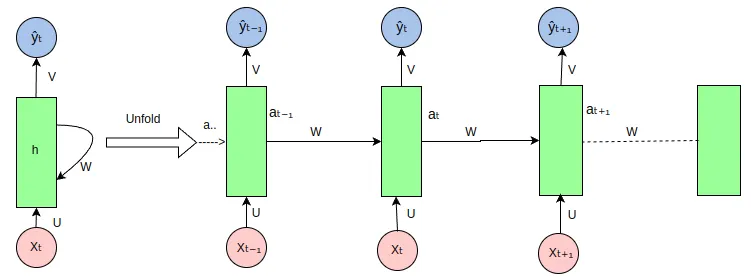

This recurrence gives the network memory.

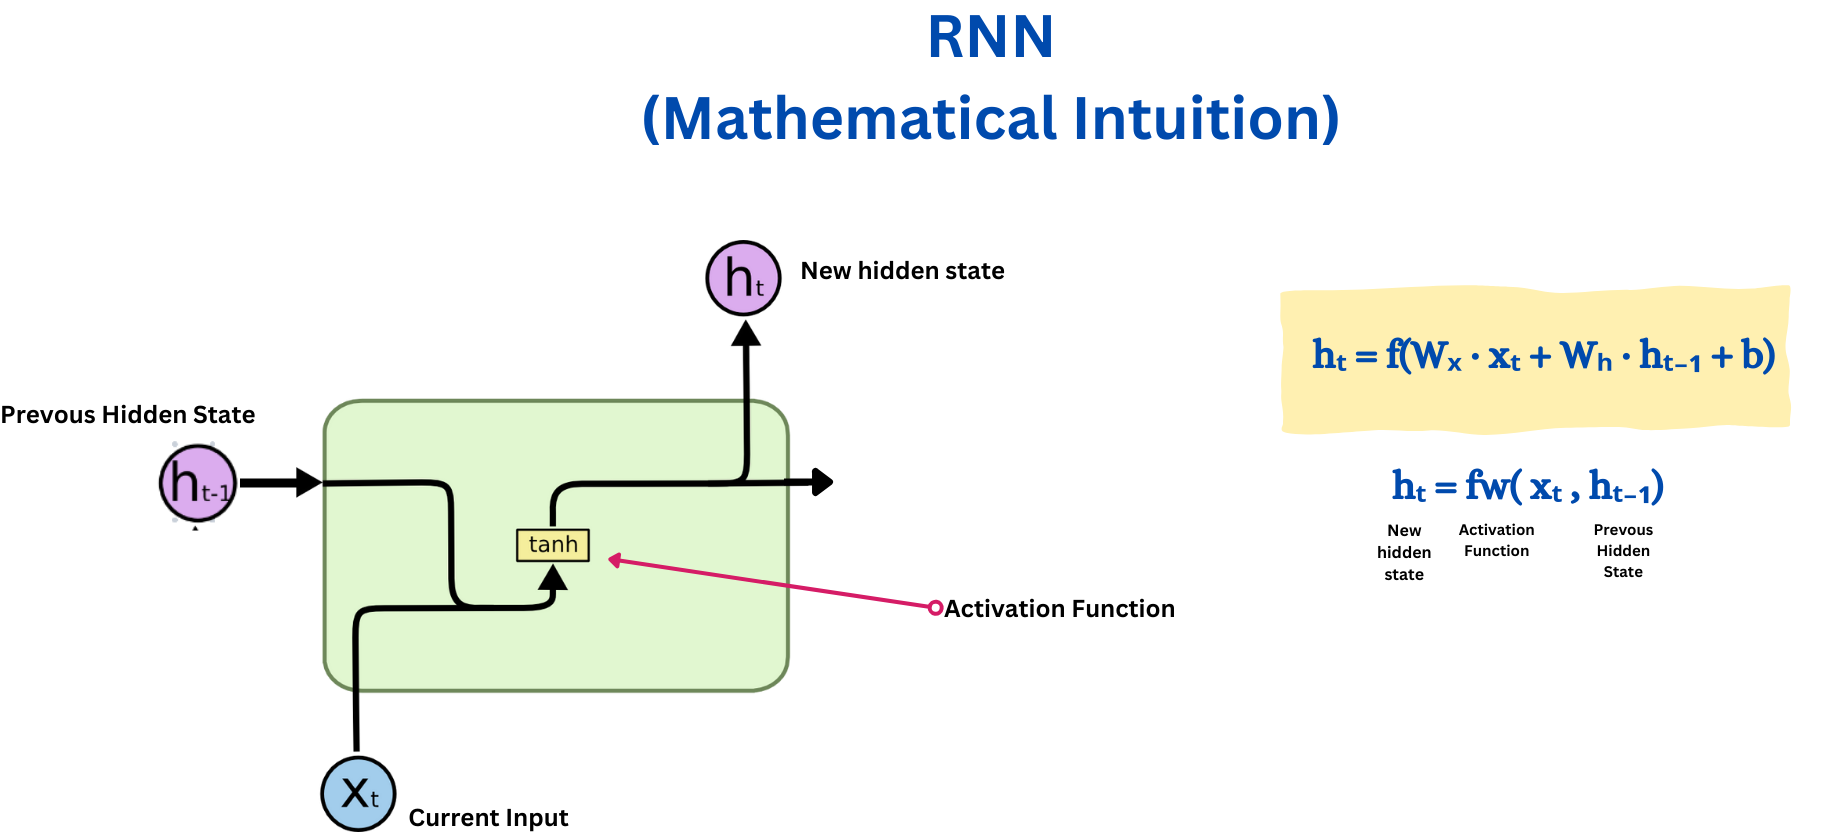

In [9]:
from keras.models import Sequential
from keras.layers import SimpleRNN
from keras.layers import Dense

In [10]:
rnn_model = Sequential([
    SimpleRNN(
        units= 8,
        input_shape= (4,1)
    ),
    Dense(1)
])

rnn_model.summary()

c:\Users\lenevo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (356.00 B)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)

# Understanding Parameters

- Sequential([...]):Creates a linear stack of layers where data flows sequentially from the input to the output.

- input_shape=(4, 1): Tells the network to expect sequential data with a length of 4 timesteps, where each step has 1 feature.

- units=8: The layer has 8 hidden neurons, meaning it will output 8 values.
The RNN maintains an internal memory vector of size 8.
This memory is updated at every time step.


- Dense(1):A standard, fully-connected output layer. It takes the 8 outputs from the RNN layer and condenses them into a single prediction (e.g., 1 continuous value for a regression task).

- rnn_model.summary():Displays a text overview of your model architecture, including the output dimensions of each layer and the total number of trainable weights.

## Parameter Breakdown
- Total params (89): The absolute number of weights and biases inside your model.

- Trainable params (89): The number of weights that will update and learn during training.

- Non-trainable params (0): There are no frozen layers, static parameters, or statistical buffers (like those found in Batch Normalization).

# Now, Feeding data to RNN

In [11]:
import numpy as np

X = np.array([
    [1,2,3,4]
])

X = X.reshape((1,4,1))

prediction = rnn_model.predict(X)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
[[-0.47169578]]


# Hidden State Intuition

Suppose we process:

I → love → machine → learning

After reading "I", the model stores information.

After reading "love", memory updates.

After reading "machine", memory updates again.

The hidden state carries information forward through time.

In [12]:
sentence = ["I", "love", "machine", "learning"]

memory = ""

for word in sentence:
    memory += word + " "
    print("Current Memory:", memory)

Current Memory: I 
Current Memory: I love 
Current Memory: I love machine 
Current Memory: I love machine learning 


# The Vanishing Gradient Problem

RNNs are trained using Backpropagation Through Time (BPTT).

Vanishing gradients occur because many small values are multiplied repeatedly during backpropagation.

For example:

0.9 × 0.9 × 0.9 × ...

After many multiplications, the value becomes extremely small.

This causes the network to stop learning information from earlier time steps.

If gradients become very small:

Gradient → 0

The network stops learning long-term dependencies.

This is called the Vanishing Gradient Problem.

# Example of Vanishing Gradient

Sentence:

"The movie that I watched three months ago was amazing."

To predict "amazing", the network should remember information from the beginning of the sentence.

In long sequences:

Information gradually fades away.

The model struggles to remember earlier words.

This causes poor performance on long-term dependencies.

In [13]:
gradient = 1.0

values = []

for i in range(30):
    gradient *= 0.9
    values.append(gradient)

values

[0.9,
 0.81,
 0.7290000000000001,
 0.6561000000000001,
 0.5904900000000002,
 0.5314410000000002,
 0.47829690000000014,
 0.43046721000000016,
 0.38742048900000015,
 0.34867844010000015,
 0.31381059609000017,
 0.28242953648100017,
 0.25418658283290013,
 0.22876792454961012,
 0.2058911320946491,
 0.1853020188851842,
 0.16677181699666577,
 0.1500946352969992,
 0.13508517176729928,
 0.12157665459056936,
 0.10941898913151243,
 0.0984770902183612,
 0.08862938119652508,
 0.07976644307687257,
 0.07178979876918531,
 0.06461081889226679,
 0.05814973700304011,
 0.0523347633027361,
 0.04710128697246249,
 0.042391158275216244]

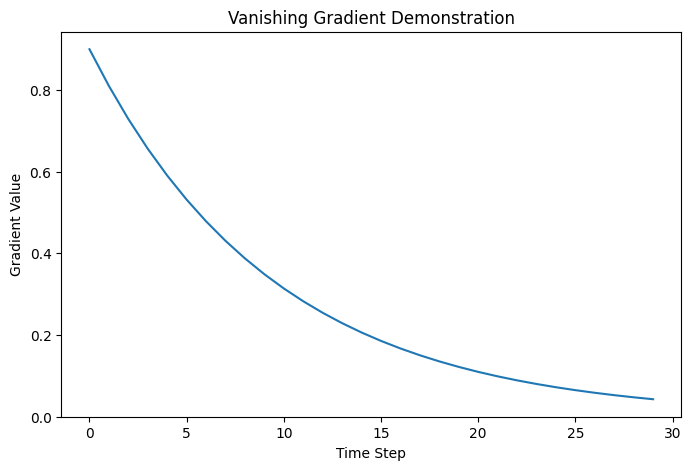

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(values)

plt.title("Vanishing Gradient Demonstration")
plt.xlabel("Time Step")
plt.ylabel("Gradient Value")

plt.show()

The curve drops toward zero.

This shows why information from earlier words becomes difficult to learn.

## Demonstrating Severe Vanishing

In [15]:
gradient = 1.0

for step in [10,20,50,100]:
    
    value = gradient * (0.9 ** step)
    
    print(f"After {step} steps: {value}")

After 10 steps: 0.3486784401000001
After 20 steps: 0.12157665459056935
After 50 steps: 0.00515377520732012
After 100 steps: 2.6561398887587544e-05


Observation:

As the sequence length increases, gradients become extremely small.

As a result, earlier information has little influence on learning.

This is the vanishing gradient problem.

# Exploding Gradient Problem

The opposite issue can also occur.

If gradients become too large:

1.2 × 1.2 × 1.2 × ...

The values grow rapidly.

This causes unstable training.

Therefore RNNs may suffer from:

1. Vanishing Gradients
2. Exploding Gradients

# Introduction to LSTM

LSTM stands for Long Short-Term Memory.

LSTM is a special type of RNN designed to solve the vanishing gradient problem.

It introduces a memory cell and gating mechanisms.

These gates control:

- What to remember
- What to forget
- What to output

# Main Components of LSTM

An LSTM contains:

1. Cell State : acts like a memory highway that carries information across long sequences.
2. Forget Gate : decides "What information should be discarded?"
3. Input Gate : decides "What new information should be stored?"
4. Output Gate: decides "What information should be passed to the next hidden state?"

The cell state acts like a memory highway that carries information across long sequences.

In [16]:
from keras.layers import LSTM

In [17]:
lstm_model = Sequential([
    LSTM(
        units=8,
        input_shape=(4,1)
    ),
    Dense(1)
])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

# Comparing RNN and LSTM Parameters

LSTMs contain additional gates.

As a result, they usually have more trainable parameters than simple RNNs.

In [18]:
print("RNN Parameters:")
print(rnn_model.count_params())

print("\nLSTM Parameters:")
print(lstm_model.count_params())

RNN Parameters:
89

LSTM Parameters:
329


# RNN vs LSTM on Sequence Prediction

We create a simple sequence:

1,2,3 → 4

2,3,4 → 5

3,4,5 → 6

The model learns the pattern and predicts the next value.

In [31]:
import numpy as np

X = []
y = []

for i in range(1, 101):
    
    X.append([i, i+1, i+2])
    y.append(i+3)

X = np.array(X)
y = np.array(y)

X = X.reshape((100,3,1))

In [32]:
# Scale data

X = X / 100.0
y = y / 100.0

## Train RNN

In [33]:
# Set random seed for reproducibility 
np.random.seed(42)
tf.random.set_seed(42)

from keras.models import Sequential
from keras.layers import SimpleRNN, Dense

rnn = Sequential([
    SimpleRNN(10, input_shape=(3,1)),
    Dense(1)
])

rnn.compile(
    optimizer="adam",
    loss="mse"
)

rnn.fit(
    X,
    y,
    epochs=500,
    verbose=0
)

## Train LSTM

In [34]:
# Set random seed for reproducibility 
np.random.seed(42)
tf.random.set_seed(42)

from keras.layers import LSTM

lstm = Sequential([
    LSTM(10, input_shape=(3,1)),
    Dense(1)
])

lstm.compile(
    optimizer="adam",
    loss="mse"
)

lstm.fit(
    X,
    y,
    epochs=500,
    verbose=0
)

## Test Both Models

In [23]:
# test 
test = np.array([[101,102,103]])

test = test / 100.0

test = test.reshape((1,3,1))


In [35]:
rnn_prediction = rnn.predict(test)

# IMPORTANT: Unscaling the prediction back to original range
rnn_prediction_unscaled = rnn_prediction * 100

print("\nRNN Prediction:")
print(rnn_prediction_unscaled)
print(f"\nExpected output: ~104")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step

RNN Prediction:
[[100.04295]]

Expected output: ~104


In [37]:
lstm_prediction = lstm.predict(test)

# IMPORTANT: Unscaling the prediction back to original range
lstm_prediction_unscaled = lstm_prediction * 100

print("\nLSTM Prediction:")
print(lstm_prediction_unscaled)
print(f"\nExpected output: ~104")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

LSTM Prediction:
[[103.11861]]

Expected output: ~104


# Comparison of RNN and LSTM Predictions

Expected Output:

104

Predictions:

- RNN: 100.04
- LSTM: 103.11

Observation:

- Both models learned the numerical sequence pattern and produced predictions close to the expected value. However, the LSTM prediction was closer to the target value, indicating its stronger ability to capture sequential dependencies.

- This demonstrates why LSTMs are generally preferred over standard RNNs for sequence learning tasks, especially when longer-term memory is required.

In [ ]:
rnn_history = rnn.fit(
    X,
    y,
    epochs=500,
    verbose=0
)

lstm_history = lstm.fit(
    X,
    y,
    epochs=500,
    verbose=0
)

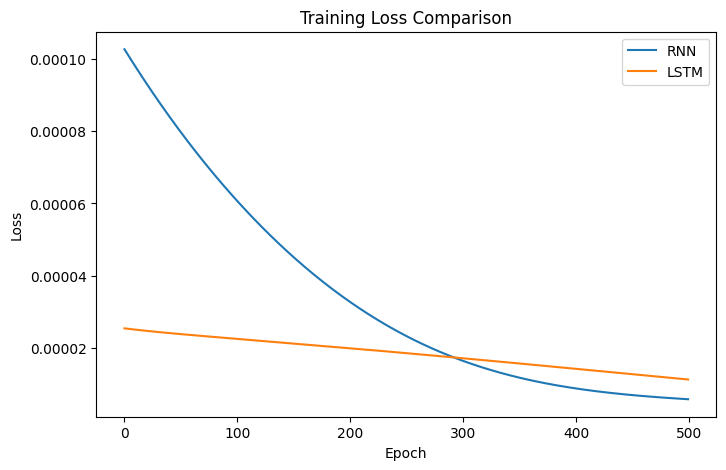

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    rnn_history.history['loss'],
    label="RNN"
)

plt.plot(
    lstm_history.history['loss'],
    label="LSTM"
)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Key Observations from  Graph:

-  **Both models learn**: Loss decreases (downward slope)
-  **LSTM performs better**: Orange line (LSTM) stays below blue line (RNN)
-  **Convergence**: Both models converge around epoch 200-300
-  **Gap narrows**: By epoch 500, both models have similar low loss, but LSTM started better

# Key Takeaways

1. RNNs process sequential data using hidden states.
2. Hidden states act as memory.
3. During backpropagation, gradients can become very small.
4. This leads to the vanishing gradient problem.
5. LSTMs introduce gates and a cell state to preserve information.
6. LSTMs are better at learning long-term dependencies.
7. For short sequences, RNN and LSTM may perform similarly.
8. For longer sequences, LSTMs generally outperform standard RNNs.